In [ ]:
%pip install pandas matplotlib seaborn scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 68.7 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
df = pd.read_csv('customer_churn_dataset.csv')
print(df.head())
print(df.dtypes)

   customer_id  tenure  monthly_charges  total_charges        contract  \
0            1      52            54.20        2818.40  Month-to-month   
1            2      15            35.28         529.20  Month-to-month   
2            3      72            78.24        5633.28  Month-to-month   
3            4      61            80.24        4894.64        One year   
4            5      21            39.38         826.98  Month-to-month   

  payment_method internet_service tech_support online_security  support_calls  \
0         Credit              DSL           No             Yes              1   
1          Debit              DSL           No              No              2   
2          Debit              DSL           No              No              0   
3           Cash            Fiber          Yes             Yes              0   
4            UPI            Fiber           No              No              4   

  churn  
0    No  
1    No  
2    No  
3    No  
4   Yes  
customer

In [14]:
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

In [15]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Columns to encode:", categorical_cols)

X = pd.get_dummies(X, columns=categorical_cols)
print(X.head())

Columns to encode: ['contract', 'payment_method', 'internet_service', 'tech_support', 'online_security']
   tenure  monthly_charges  total_charges  support_calls  \
0      52            54.20        2818.40              1   
1      15            35.28         529.20              2   
2      72            78.24        5633.28              0   
3      61            80.24        4894.64              0   
4      21            39.38         826.98              4   

   contract_Month-to-month  contract_One year  contract_Two year  \
0                     True              False              False   
1                     True              False              False   
2                     True              False              False   
3                    False               True              False   
4                     True              False              False   

   payment_method_Cash  payment_method_Credit  payment_method_Debit  \
0                False                   True         

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [17]:
from sklearn.model_selection import train_test_split

# 20% goes to testing, 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

Training rows: 16000, Test rows: 4000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
svm     = SVC(probability=True, class_weight="balanced")
rf      = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")

log_reg.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": log_reg,
    "SVM":                 svm,
    "Random Forest":       rf
}

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  Accuracy: {acc:.2%}")
    print(classification_report(y_test, preds, target_names=["No Churn", "Churn"]))


  Logistic Regression
  Accuracy: 72.22%
              precision    recall  f1-score   support

    No Churn       0.84      0.72      0.77      2645
       Churn       0.57      0.74      0.64      1355

    accuracy                           0.72      4000
   macro avg       0.71      0.73      0.71      4000
weighted avg       0.75      0.72      0.73      4000


  SVM
  Accuracy: 80.50%
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.85      2645
       Churn       0.73      0.68      0.70      1355

    accuracy                           0.81      4000
   macro avg       0.78      0.77      0.78      4000
weighted avg       0.80      0.81      0.80      4000


  Random Forest
  Accuracy: 84.45%
              precision    recall  f1-score   support

    No Churn       0.85      0.93      0.89      2645
       Churn       0.83      0.68      0.75      1355

    accuracy                           0.84      4000
   macro avg       0.84 

In [26]:
results = pd.DataFrame({
    'Actual':              le.inverse_transform(y_test),
    'Logistic Regression': le.inverse_transform(log_reg.predict(X_test)),
    'SVM':                 le.inverse_transform(svm.predict(X_test)),
    'Random Forest':       le.inverse_transform(rf.predict(X_test))
})

print(results.head(20))

disagreements = results[
    (results['Logistic Regression'] != results['SVM']) |
    (results['SVM'] != results['Random Forest'])
]

print(f"\nRows where models disagree: {len(disagreements)}")
print(disagreements.head(10))

   Actual Logistic Regression  SVM Random Forest
0     Yes                 Yes  Yes           Yes
1      No                  No   No            No
2      No                  No   No            No
3     Yes                 Yes  Yes           Yes
4     Yes                 Yes   No           Yes
5     Yes                 Yes  Yes           Yes
6     Yes                 Yes  Yes           Yes
7     Yes                 Yes  Yes           Yes
8     Yes                 Yes  Yes           Yes
9     Yes                  No   No            No
10     No                  No   No            No
11    Yes                  No   No            No
12     No                  No   No            No
13     No                  No   No            No
14    Yes                  No   No            No
15    Yes                 Yes  Yes           Yes
16     No                  No   No            No
17     No                  No   No            No
18     No                  No   No            No
19     No           

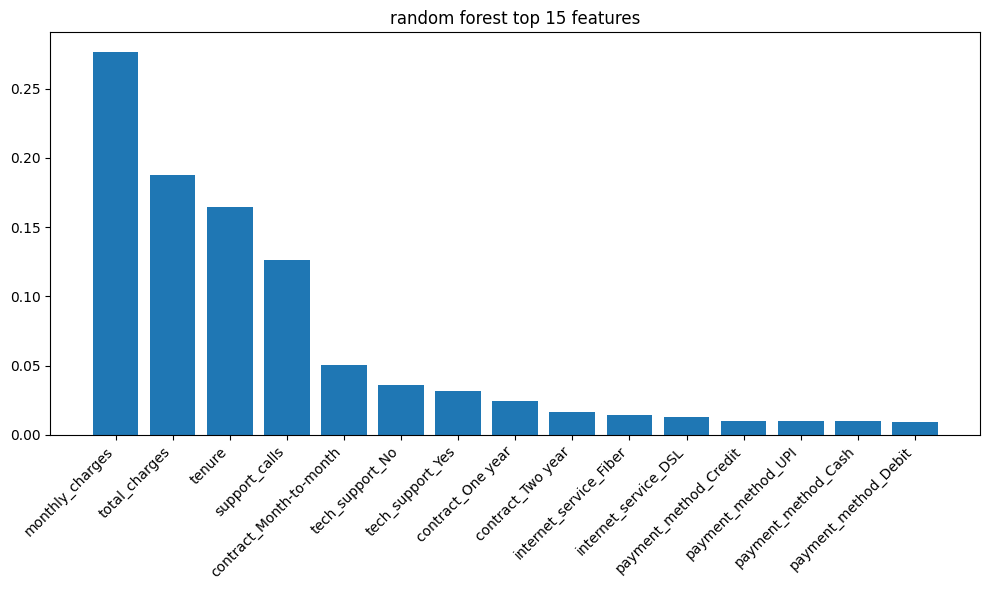

feature rankings:
  1. monthly_charges                     0.2768
  2. total_charges                       0.1877
  3. tenure                              0.1648
  4. support_calls                       0.1261
  5. contract_Month-to-month             0.0506
  6. tech_support_No                     0.0362
  7. tech_support_Yes                    0.0316
  8. contract_One year                   0.0245
  9. contract_Two year                   0.0167
  10. internet_service_Fiber              0.0143
  11. internet_service_DSL                0.0131
  12. payment_method_Credit               0.0102
  13. payment_method_UPI                  0.0101
  14. payment_method_Cash                 0.0098
  15. payment_method_Debit                0.0096


In [27]:
# featuer importance
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("random forest top 15 features")
plt.bar(range(15), importances[indices[:15]])
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("feature rankings:")
for i, idx in enumerate(indices[:15]):
    print(f"  {i+1}. {feature_names[idx]:<35} {importances[idx]:.4f}")